<a href="https://colab.research.google.com/github/mathivathani-1411/mathivathani-codebooster-2026/blob/main/Day2/Miniproject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"panads version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")


All libraries imported successfully!
panads version:2.2.2
sqlite3 version:2.6.0


In [2]:
df=pd.read_csv('student_performance.csv')

In [3]:
conn=sqlite3.connect("college.db")
cursor=conn.cursor()
df.to_sql(
    'students', #table name
    conn,  #connect to the database
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")

count=cursor.fetchone()[0]
print(f"Database 'college.db' created succesfully")
print(f"Table 'students' has {count} rows")

Database 'college.db' created succesfully
Table 'students' has 31 rows


In [4]:
def run_query(sql, description="student"):
    if description:
        print(f"\n{'=' * 55}")
        print(f"{description}")
        print(f"{'=' * 55}")

    result = pd.read_sql_query(sql, conn)
    return result

print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")


Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


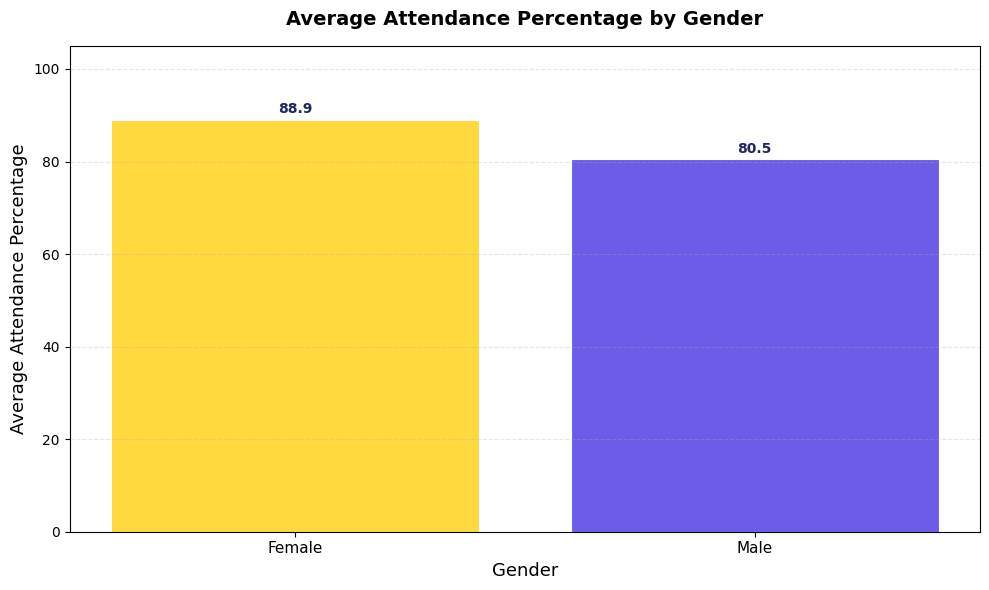

In [7]:
chart1_sql = """
SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_attend
FROM students
GROUP BY gender
ORDER BY avg_attend DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = [ '#FFD93D', '#6C5CE7']

bars = ax.bar(
    chart1_data['gender'],
    chart1_data['avg_attend'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Attendance Percentage by Gender',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Gender', fontsize=13)
ax.set_ylabel('Average Attendance Percentage', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

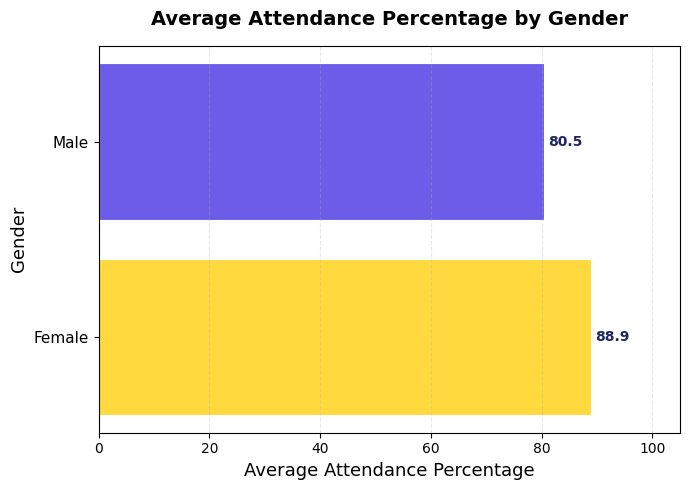

In [23]:
chart1_sql = """
SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_attend
FROM students
GROUP BY gender
ORDER BY avg_attend DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(7, 5))

bar_colors = ['#FFD93D', '#6C5CE7']

bars = ax.barh(
    chart1_data['gender'],
    chart1_data['avg_attend'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Attendance Percentage by Gender',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Average Attendance Percentage', fontsize=13)
ax.set_ylabel('Gender', fontsize=13)

ax.set_xlim(0, 105)

ax.tick_params(axis='y', labelsize=11)

ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

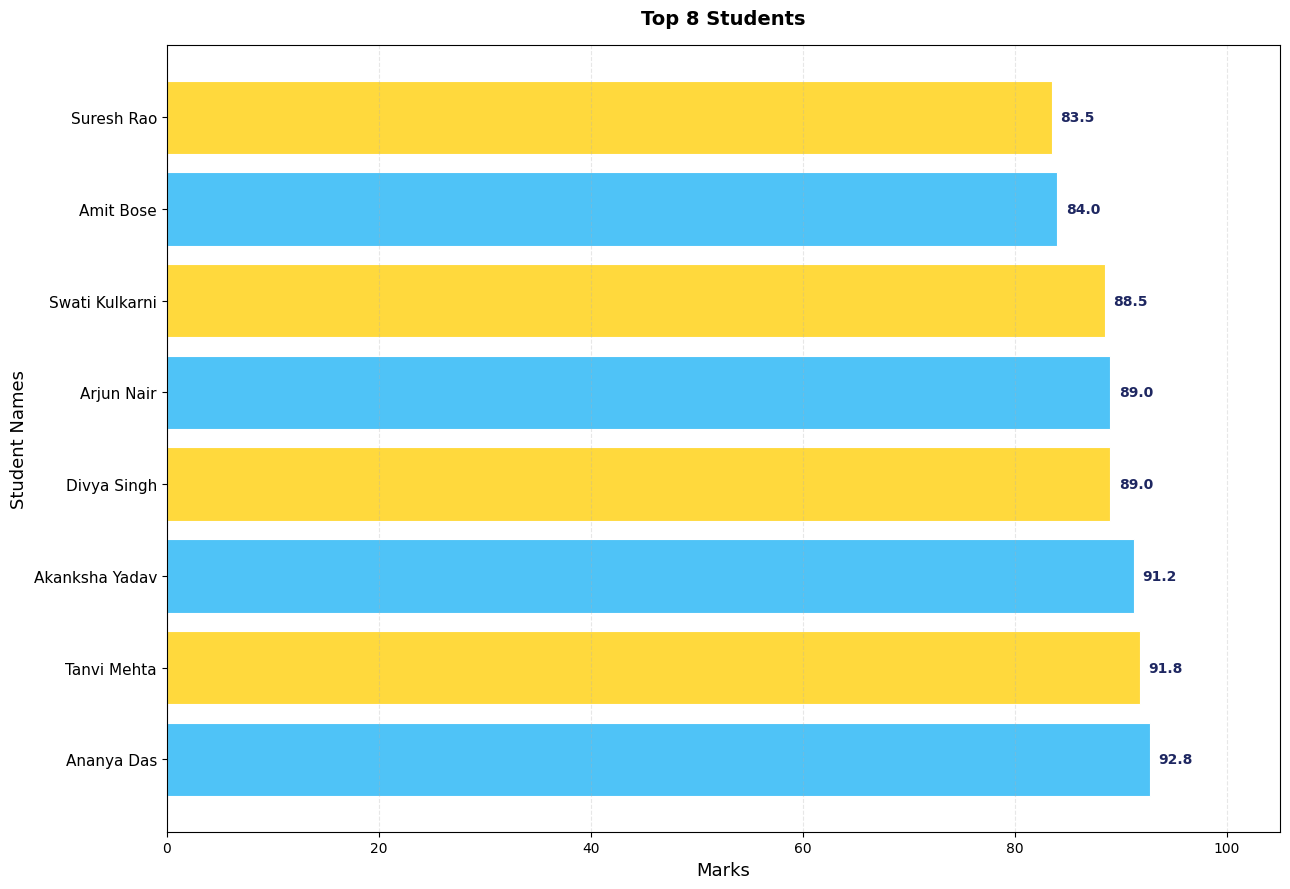

In [22]:
chart1_sql = """
SELECT name,
ROUND(math_score+english_score+programming_score+science_score)/4 AS avg_marks
FROM students
GROUP BY name
ORDER BY avg_marks DESC
LIMIT 8
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(13, 9))

bar_colors = [ '#4FC3F7','#FFD93D']

bars = ax.barh(
    chart1_data['name'],
    chart1_data['avg_marks'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Top 8 Students',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Marks', fontsize=13)
ax.set_ylabel('Student Names', fontsize=13)

ax.set_xlim(0, 105)

ax.tick_params(axis='y', labelsize=11)

ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()